In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns

In [41]:
df = pd.read_csv("data/Cleaned_Asteroid_Updated.csv", low_memory=False)
df.head()

,a,e,i,om,w,q,ad,per_y,data_arc,n_obs_used,...,class_APO,class_AST,class_ATE,class_CEN,class_IMB,class_MBA,class_MCA,class_OMB,class_TJN,class_TNO
0,2.769165,0.076009,10.594067,80.305532,73.597694,2.558684,2.979647,4.608202,8822.0,1002,...,False,False,False,False,False,True,False,False,False,False
1,2.772466,0.230337,34.836234,173.080063,310.048857,2.133865,3.411067,4.616444,72318.0,8490,...,False,False,False,False,False,True,False,False,False,False
2,2.669150,0.256942,12.988919,169.852760,248.138626,1.983332,3.354967,4.360814,72684.0,7104,...,False,False,False,False,False,True,False,False,False,False
3,2.361418,0.088721,7.141771,103.810804,150.728541,2.151909,2.570926,3.628837,24288.0,9325,...,False,False,False,False,False,True,False,False,False,False
4,2.574249,0.191095,5.366988,141.576605,358.687607,2.082324,3.066174,4.130323,63507.0,2916,...,False,False,False,False,False,True,False,False,False,False


In [ ]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(11, 9))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})


In [42]:
df_tmp = df.copy()
df_tmp.rename(columns={'diameter': 'Target'}, inplace=True)
df_tmp['Target'].head()

0    939.400
1    545.000
2    246.596
3    525.400
4    106.699
Name: Target, dtype: float64

In [47]:
df_tmp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136406 entries, 0 to 136405
Data columns (total 42 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   a                 136406 non-null  float64
 1   e                 136406 non-null  float64
 2   i                 136406 non-null  float64
 3   om                136406 non-null  float64
 4   w                 136406 non-null  float64
 5   q                 136406 non-null  float64
 6   ad                136406 non-null  float64
 7   per_y             136406 non-null  float64
 8   data_arc          136406 non-null  float64
 9   n_obs_used        136406 non-null  int64  
 10  H                 136406 non-null  float64
 11  Target            136406 non-null  float64
 12  albedo            136406 non-null  float64
 13  moid              136406 non-null  float64
 14  n                 136406 non-null  float64
 15  per               136406 non-null  float64
 16  ma                13

In [43]:
df_shuffled = df_tmp.sample(frac=1, random_state=42).reset_index(drop=True)
df_shuffled.head()

,a,e,i,om,w,q,ad,per_y,data_arc,n_obs_used,...,class_APO,class_AST,class_ATE,class_CEN,class_IMB,class_MBA,class_MCA,class_OMB,class_TJN,class_TNO
0,2.799586,0.102615,17.971012,147.589576,331.691727,2.512307,3.086866,4.684346,8885.0,1103,...,False,False,False,False,False,True,False,False,False,False
1,3.127158,0.017226,9.850152,74.589438,108.005160,3.073290,3.181025,5.530098,3601.0,222,...,False,False,False,False,False,True,False,False,False,False
2,2.624948,0.204094,12.635218,44.164821,31.370090,2.089213,3.160683,4.252940,6385.0,613,...,False,False,False,False,False,True,False,False,False,False
3,3.166418,0.135768,27.955869,334.307321,162.338977,2.736519,3.596316,5.634566,5800.0,160,...,False,False,False,False,False,True,False,False,False,False
4,3.088201,0.186497,17.040372,247.239945,140.706012,2.512260,3.664141,5.427083,12047.0,722,...,False,False,False,False,False,True,False,False,False,False


In [44]:
n = len(df_shuffled)
train_end = int(0.8 * n)
val_end = int(0.9 * n)

df_train = df_shuffled[:train_end]
df_val = df_shuffled[train_end:val_end]
df_test = df_shuffled[val_end:]

In [70]:
def to_tensor_dataset(df_subset, scaler=None):
    X = df_subset.drop(columns=['Target'], axis=1).astype('float32').values
    y = df_subset['Target'].astype('float32').values.reshape(-1, 1)

    if scaler is None:
        scaler = MinMaxScaler()
        X = scaler.fit_transform(X)
    else:
        X = scaler.transform(X)
    
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32)
    return torch.utils.data.TensorDataset(X, y), scaler

In [71]:
train_dataset, scaler = to_tensor_dataset(df_train)
val_dataset, _ = to_tensor_dataset(df_val, scaler)
test_dataset, _ = to_tensor_dataset(df_test, scaler)

In [72]:
BATCH_SIZE=32
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [73]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device

device(type='cuda')

In [74]:
INPUT_SIZE = df_tmp.drop(columns=['Target']).shape[1]
INPUT_SIZE

41

In [89]:
class MultilayerPerceptron(nn.Module):
    def __init__(self, in_size, hid_size) -> None:
        super().__init__()
        self.l1 = nn.Linear(in_size, hid_size)
        self.bn1 = nn.BatchNorm1d(hid_size)
        self.l2 = nn.Linear(hid_size, hid_size)
        self.bn2 = nn.BatchNorm1d(hid_size)
        self.l3 = nn.Linear(hid_size, hid_size)
        self.bn3 = nn.BatchNorm1d(hid_size)
        self.out = nn.Linear(hid_size, 1)

    def forward(self, x):
        x = F.relu(self.bn1(self.l1(x)))
        x = F.relu(self.bn2(self.l2(x)))
        x = F.relu(self.bn3(self.l3(x)))
        return self.out(x)

In [92]:
model = MultilayerPerceptron(in_size=INPUT_SIZE, hid_size=60).to(device)
optim = torch.optim.Adam(params=model.parameters(), lr=0.00001)
loss_fn = nn.MSELoss()

In [93]:
EPOCHS=50

for epoch in range(EPOCHS):
    print('Epoch {}'.format(epoch + 1))

    model.train()
    for features, target in train_loader:
        features = features.to(device)
        target = target.to(device)

        optim.zero_grad()
        output = model(features)
        loss = loss_fn(output, target)
        loss.backward()
        optim.step()

    model.eval()
    val_losses = []
    val_predictions = []
    val_targets = []
    for features, target in val_loader:
        features = features.to(device)
        target = target.to(device)

        with torch.no_grad():
            output = model(features)
            val_predictions.append(output.cpu().numpy())
            val_targets.append(target.cpu().numpy())
            loss = loss_fn(output, target)
            val_losses.append(loss.item())

    avg_loss = np.mean(val_losses)
    print('Validation Loss: {:.4f}'.format(avg_loss))
    
    val_predictions = np.concatenate(val_predictions, axis=0)
    val_targets = np.concatenate(val_targets, axis=0)

    dummy_array = np.zeros((len(val_predictions), INPUT_SIZE))
    dummy_array[:, 0] = val_predictions.flatten()
    inverted_predictions = scaler.inverse_transform(dummy_array)[:, 0]

    error = np.mean(np.abs(inverted_predictions - val_targets.flatten()))
    print('Validation Error (Original Scale): {:.4f}'.format(error))



Epoch 1
Validation Loss: 100.5804
Validation Error (Original Scale): 271.5249
Epoch 2
Validation Loss: 81.3005
Validation Error (Original Scale): 450.9455
Epoch 3
Validation Loss: 65.1157
Validation Error (Original Scale): 705.3053
Epoch 4
Validation Loss: 64.0641
Validation Error (Original Scale): 714.3455
Epoch 5
Validation Loss: 47.5649
Validation Error (Original Scale): 1142.1366
Epoch 6
Validation Loss: 45.5497
Validation Error (Original Scale): 1304.7431
Epoch 7
Validation Loss: 38.2412
Validation Error (Original Scale): 1524.8479
Epoch 8
Validation Loss: 38.5571
Validation Error (Original Scale): 1554.4162
Epoch 9
Validation Loss: 32.9204
Validation Error (Original Scale): 1778.2550
Epoch 10
Validation Loss: 33.3352
Validation Error (Original Scale): 1715.9423
Epoch 11
Validation Loss: 30.0759
Validation Error (Original Scale): 1949.6289
Epoch 12
Validation Loss: 27.8161
Validation Error (Original Scale): 1885.0948
Epoch 13
Validation Loss: 25.8102
Validation Error (Original Sca

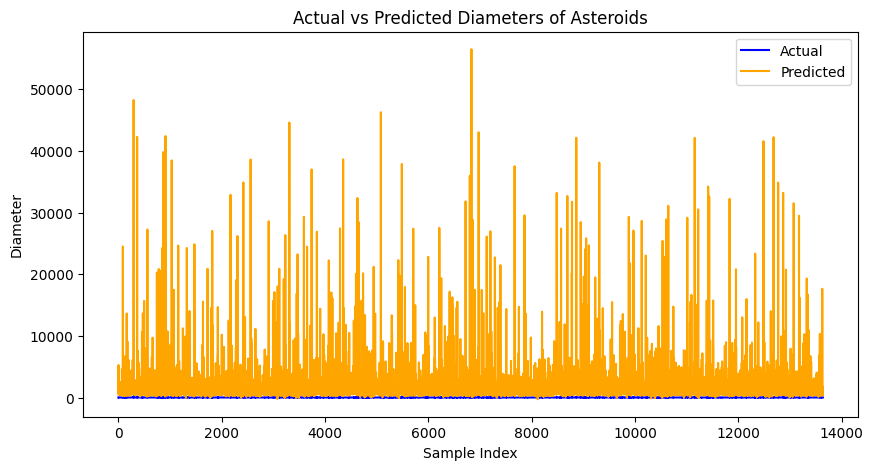

In [94]:
model.eval()
predictions = []
test_targets = []
for features, target in test_loader:
    features = features.to(device)
    target = target.to(device)

    with torch.no_grad():
        output = model(features)
        predictions.append(output.cpu().numpy())
        test_targets.append(target.cpu().numpy())

predictions = np.concatenate(predictions, axis=0)
test_targets = np.concatenate(test_targets, axis=0)

# Create a dummy array with the same number of samples and features as the original data
dummy_array = np.zeros((len(predictions), INPUT_SIZE))

# Replace the first column of the dummy array with the predictions
dummy_array[:, 0] = predictions.flatten()

# Inverse transform the dummy array
inverted_predictions = scaler.inverse_transform(dummy_array)[:, 0]

plt.figure(figsize=(10, 5))
plt.plot(test_targets, label='Actual', color='blue')
plt.plot(inverted_predictions, label='Predicted', color='orange')
plt.xlabel('Sample Index')
plt.ylabel('Diameter')
plt.title('Actual vs Predicted Diameters of Asteroids')
plt.legend()
plt.show()